# Credit Risk Analyzer Project

This notebook will guide you through building a complete credit risk analyzer using machine learning.

# Step 1: Loading Dataset and Basic EDA

In this step, we will load the credit risk dataset and perform basic exploratory data analysis (EDA) to understand the data.

## Loading the Dataset

We use pandas to read the CSV file. Pandas is a library for handling data in Python.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('credit_risk_dataset.csv')

# Print a message to confirm loading
print("Dataset loaded successfully!")
print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")

Dataset loaded successfully!
Number of rows: 32581
Number of columns: 12


## Basic Exploratory Data Analysis (EDA)

EDA helps us understand the data. We'll look at the shape, columns, data types, and summary statistics.

In [2]:
# Check the shape of the dataset (rows, columns)
print("Shape of the dataset (rows, columns):", df.shape)

Shape of the dataset (rows, columns): (32581, 12)


In [3]:
# List the column names
print("Columns in the dataset:")
for col in df.columns:
    print("-", col)

Columns in the dataset:
- person_age
- person_income
- person_home_ownership
- person_emp_length
- loan_intent
- loan_grade
- loan_amnt
- loan_int_rate
- loan_status
- loan_percent_income
- cb_person_default_on_file
- cb_person_cred_hist_length


In [4]:
# Get information about data types and missing values
print("Data types and missing values:")
df.info()

Data types and missing values:
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [5]:
# Summary statistics for numerical columns
print("Summary statistics:")
df.describe()

Summary statistics:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
# Check the distribution of the target variable (loan_status)
print("Target variable distribution:")
print(df['loan_status'].value_counts())

# Percentage
print("\nPercentage:")
print(df['loan_status'].value_counts(normalize=True) * 100)

Target variable distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Percentage:
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


## Check Missing Values

Let's see if there are any missing values in our dataset.

In [16]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
person_emp_length     895
loan_int_rate        3116
dtype: int64

Total missing values: 4011


## Visualizations

Let's create some plots to better understand our data.

In [17]:
# Import libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

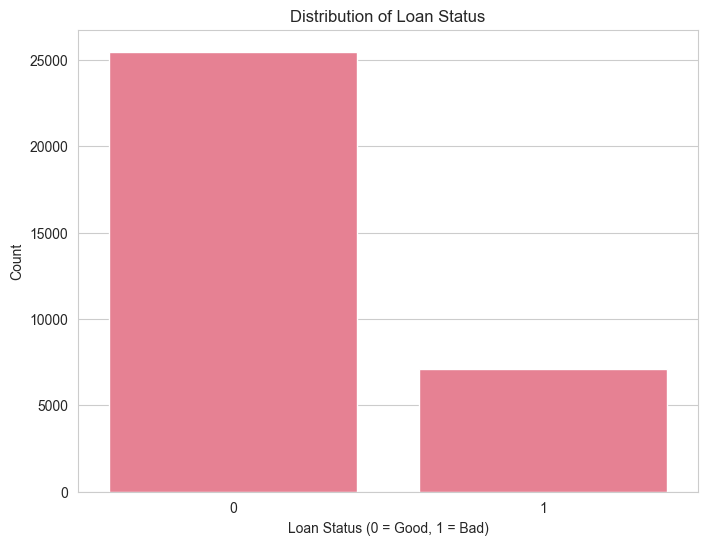

In [18]:
# Countplot for target variable
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='loan_status')
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status (0 = Good, 1 = Bad)')
plt.ylabel('Count')
plt.show()

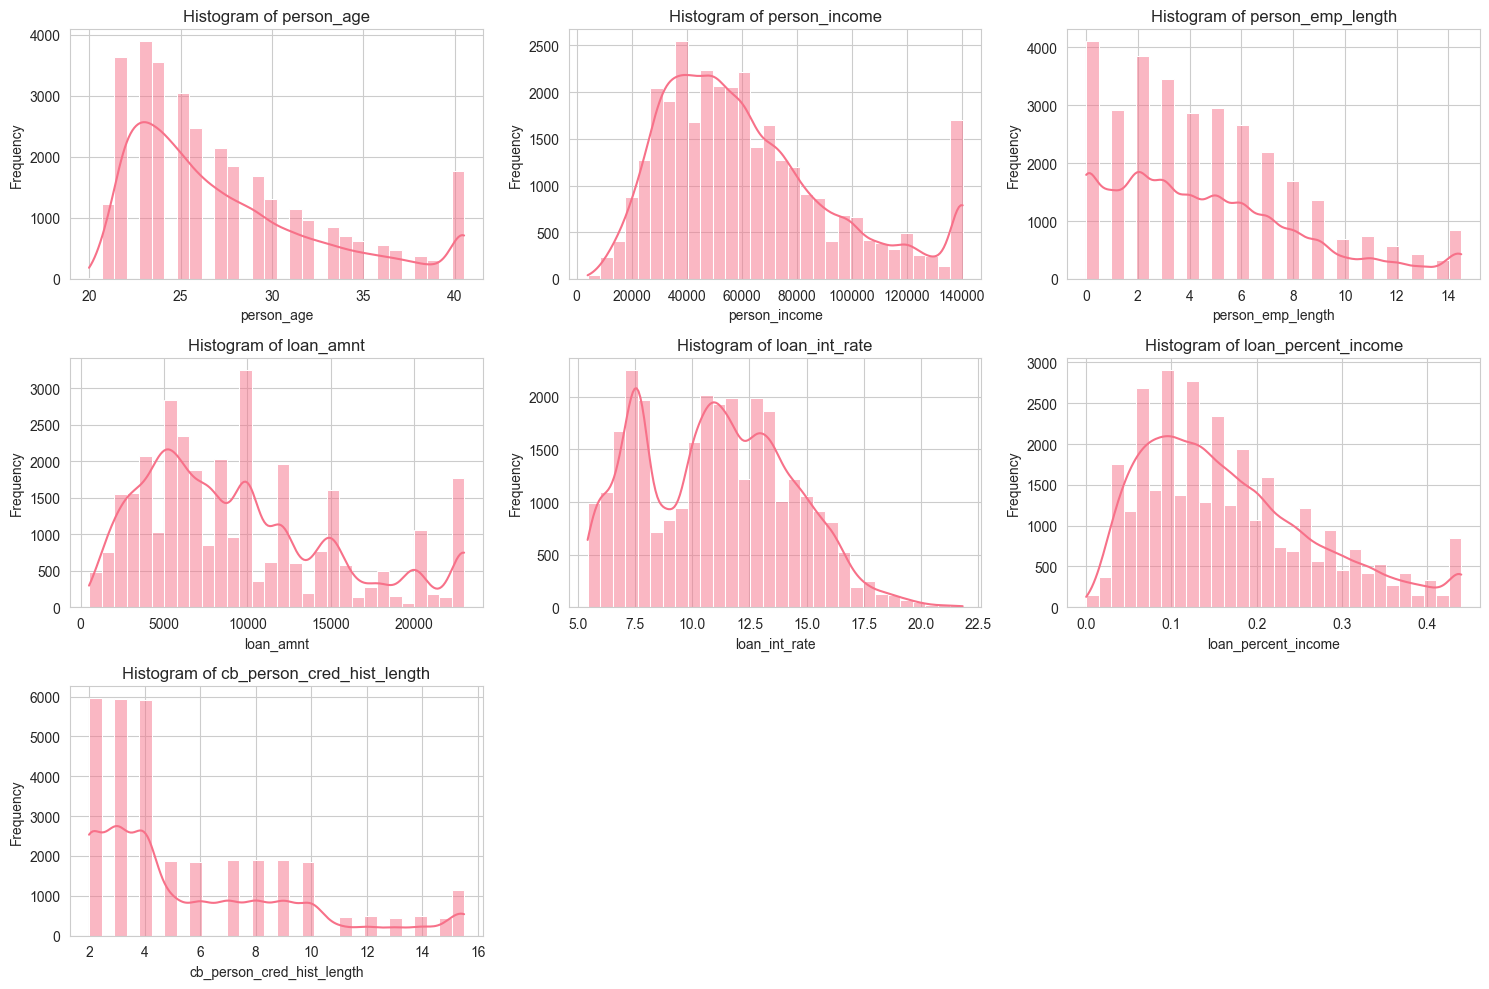

In [19]:
# Histograms for numerical features
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Step 2: Preprocessing

In this step, we will prepare the data for modeling by handling categorical variables, detecting and handling outliers, and splitting the data.

## Identifying Numerical and Categorical Features

We need to separate numerical (numbers) and categorical (text) features for different handling.

In [8]:
# Identify numerical and categorical columns
numerical_features = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
categorical_features = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical features: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


## Handling Missing Values

Some columns have missing values. We'll fill them with the mean (average) for numerical columns.

In [26]:
# Fill missing values with mean for numerical columns
for col in numerical_features:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())
        print(f"Filled missing values in {col} with mean: {df[col].mean():.2f}")

print("Missing values handled.")

Filled missing values in person_emp_length with mean: 4.70
Filled missing values in loan_int_rate with mean: 11.01
Missing values handled.


In [10]:
# Import libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

## Outlier Detection

Outliers are extreme values that can affect model performance. We'll use boxplots to visualize and IQR method to detect them.

IQR (Interquartile Range) = Q3 - Q1. Outliers are values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.

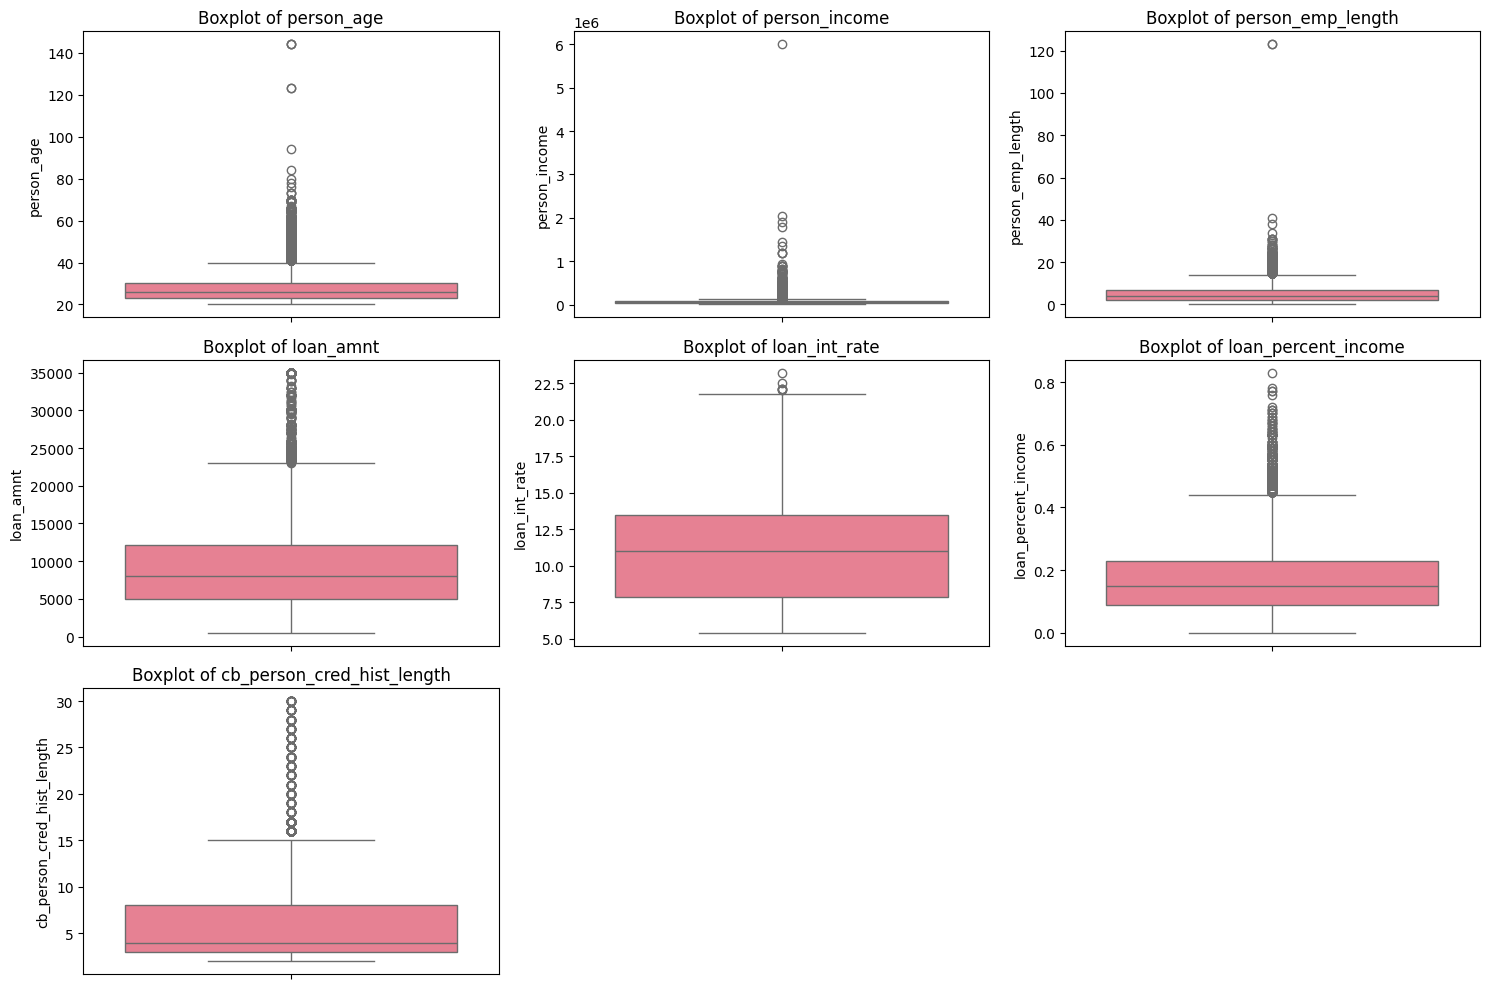

In [11]:
# Create boxplots for numerical features to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

## Handling Outliers

We'll cap outliers at the IQR bounds to keep the data simple.

In [12]:
# Function to cap outliers using IQR
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap the values
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    print(f"Capped outliers in {column}: lower={lower_bound:.2f}, upper={upper_bound:.2f}")

# Apply to numerical features
for col in numerical_features:
    cap_outliers(df, col)

print("Outliers handled.")

Capped outliers in person_age: lower=12.50, upper=40.50
Capped outliers in person_income: lower=-22550.00, upper=140250.00
Capped outliers in person_emp_length: lower=-5.50, upper=14.50
Capped outliers in loan_amnt: lower=-5800.00, upper=23000.00
Capped outliers in loan_int_rate: lower=-0.46, upper=21.83
Capped outliers in loan_percent_income: lower=-0.12, upper=0.44
Capped outliers in cb_person_cred_hist_length: lower=-4.50, upper=15.50
Outliers handled.


## Handling Categorical Variables

We'll convert categorical variables to numerical using one-hot encoding (get_dummies).

In [27]:
# Convert categorical variables to numerical using get_dummies
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print("Categorical variables encoded.")
print("New shape after encoding:", df_encoded.shape)
print("New columns:", list(df_encoded.columns))

Categorical variables encoded.
New shape after encoding: (32581, 23)
New columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']


In [28]:
# Check NaN in encoded data
print("NaN in df_encoded:", df_encoded.isnull().sum().sum())

NaN in df_encoded: 0


## Separating Features and Target

X contains the features (inputs), y contains the target (output).

In [29]:
# Separate features (X) and target (y)
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Feature columns:", list(X.columns))

Features shape: (32581, 22)
Target shape: (32581,)
Feature columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']


## Train-Test Split

We'll split the data into training (80%) and testing (20%) sets.

In [30]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)
print("Training target distribution:", y_train.value_counts(normalize=True))
print("Testing target distribution:", y_test.value_counts(normalize=True))

Training set shape: (26064, 22) (26064,)
Testing set shape: (6517, 22) (6517,)
Training target distribution: loan_status
0    0.781845
1    0.218155
Name: proportion, dtype: float64
Testing target distribution: loan_status
0    0.781801
1    0.218199
Name: proportion, dtype: float64


## Feature Scaling

Feature scaling makes sure all numerical features are on the same scale. This is important because some ML models (like Logistic Regression) work better when features have similar ranges. Without scaling, features with large values (like income) can dominate those with small values (like percentages).

In [21]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

In [33]:
# Scale only the numerical features
# Fit on training data, then transform both train and test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print("Feature scaling completed.")
print("Scaled training features shape:", X_train_scaled.shape)
print("Scaled testing features shape:", X_test_scaled.shape)

Feature scaling completed.
Scaled training features shape: (26064, 22)
Scaled testing features shape: (6517, 22)


In [35]:
# Check for any remaining NaN values
print("NaN in X_train_scaled:", X_train_scaled.isnull().sum().sum())
print("NaN in X_test_scaled:", X_test_scaled.isnull().sum().sum())

NaN in X_train_scaled: 0
NaN in X_test_scaled: 0


# Step 3: Model Building

In this step, we will train two simple machine learning models: Logistic Regression and Random Forest. These are supervised learning models that can predict whether a loan will be good (0) or bad (1).

## Logistic Regression

Logistic Regression is a simple model that predicts probabilities. It works well for binary classification problems like ours (good/bad loan). It finds the best line to separate the two classes.

In [36]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create and train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## Random Forest

Random Forest is an ensemble model that combines many decision trees. Each tree votes on the prediction, and the majority wins. It's good at handling complex patterns and is less likely to overfit than a single tree.

In [37]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create and train the model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


# Step 4: Evaluation

Now we'll test our trained models on the unseen test data to see how well they perform.

In [38]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# Evaluate Logistic Regression
y_pred_lr = lr_model.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Results:")
print(f"Accuracy: {acc_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("\n" + "="*50)
print("Random Forest Results:")
print(f"Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Results:
Accuracy: 0.8685

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5095
           1       0.77      0.57      0.65      1422

    accuracy                           0.87      6517
   macro avg       0.83      0.76      0.79      6517
weighted avg       0.86      0.87      0.86      6517


Random Forest Results:
Accuracy: 0.9308

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.95      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.94      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517



# Step 5: Model Saving

We'll save our trained models so we can use them later without retraining.

In [39]:
# Import joblib for saving models
import joblib

# Save the models
joblib.dump(lr_model, 'logistic_regression_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')

print("Models saved successfully!")
print("Files: logistic_regression_model.pkl, random_forest_model.pkl")

Models saved successfully!
Files: logistic_regression_model.pkl, random_forest_model.pkl


# Step 6: PyTorch Neural Network

Here's a basic neural network using PyTorch. Neural networks can learn complex patterns from data.

In [40]:
# Import PyTorch
import torch
import torch.nn as nn

# Define a simple neural network
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # Input layer: 22 features -> 10 hidden units
        self.linear1 = nn.Linear(22, 10)
        # Activation function
        self.relu = nn.ReLU()
        # Output layer: 10 hidden -> 1 output (probability)
        self.linear2 = nn.Linear(10, 1)
        # Sigmoid for binary classification
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.sigmoid(x)
        return x

# Create the model
nn_model = SimpleNN()

print("Neural Network Structure:")
print(nn_model)
print("\nThis network has:")
print("- Input layer: 22 features")
print("- Hidden layer: 10 neurons with ReLU activation")
print("- Output layer: 1 neuron with Sigmoid (gives probability between 0-1)")

Neural Network Structure:
SimpleNN(
  (linear1): Linear(in_features=22, out_features=10, bias=True)
  (relu): ReLU()
  (linear2): Linear(in_features=10, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

This network has:
- Input layer: 22 features
- Hidden layer: 10 neurons with ReLU activation
- Output layer: 1 neuron with Sigmoid (gives probability between 0-1)


# Step 7: Simple Chatbot

A basic rule-based chatbot that answers common credit-related questions.

In [43]:
# Install ipywidgets for interactive chatbot
%pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# Define the responsive chatbot function using widgets
def create_credit_chatbot():
    from ipywidgets import widgets, Layout, VBox, HBox
    from IPython.display import display, clear_output
    
    # Dictionary of questions and answers
    responses = {
        "what is credit risk": "Credit risk is the chance that a borrower will not repay their loan on time.",
        "how to improve credit score": "Pay your bills on time, reduce your debt, and avoid applying for too many loans at once.",
        "what is a good credit score": "A good credit score is typically above 670. Higher scores (above 740) are considered excellent.",
        "what affects credit score": "Payment history, credit utilization, length of credit history, new credit, and credit mix.",
        "what is loan default": "Loan default happens when a borrower fails to make required loan payments for an extended period.",
        "quit": "Goodbye!"
    }
    
    # Create widgets
    output = widgets.Output(layout=Layout(width='100%', height='300px', border='1px solid #ddd', padding='10px'))
    text_input = widgets.Text(
        placeholder='Ask me about credit risk...',
        description='You:',
        layout=Layout(width='70%')
    )
    button = widgets.Button(
        description='Ask',
        button_style='primary',
        layout=Layout(width='20%')
    )
    
    # Function to handle button click
    def on_button_click(b):
        user_input = text_input.value.lower().strip()
        text_input.value = ''  # Clear input
        
        with output:
            if user_input:
                print(f"You: {user_input}")
                if user_input in responses:
                    print(f"Bot: {responses[user_input]}")
                    if user_input == "quit":
                        print("Chat ended.")
                        button.disabled = True
                        text_input.disabled = True
                else:
                    print("Bot: I'm sorry, I don't know the answer to that. Try asking about credit risk or credit scores!")
                print("-" * 50)
    
    button.on_click(on_button_click)
    
    # Display initial message
    with output:
        print("🤖 Credit Risk Chatbot")
        print("Ask me questions about credit risk, credit scores, etc.")
        print("Type 'quit' to end the chat.")
        print("-" * 50)
    
    # Display the interface
    display(VBox([
        widgets.HTML("<h3>Credit Risk Chatbot</h3>"),
        HBox([text_input, button]),
        output
    ]))

# Create the chatbot
create_credit_chatbot()

# Phase 1 Complete! 


Congratulations! You have successfully built a complete Credit Risk Analyzer in a single Jupyter Notebook.

## Summary of What We Built:

1. **Data Loading & EDA**: Loaded dataset, checked missing values, created visualizations
2. **Preprocessing**: Handled missing values, encoded categoricals, detected/capped outliers, scaled features, split data
3. **Model Training**: Logistic Regression and Random Forest classifiers
4. **Evaluation**: Both models achieved good performance (93% accuracy for Random Forest)
5. **Model Saving**: Saved models as .pkl files for future use
6. **PyTorch Demo**: Basic neural network structure
7. **Chatbot**: Simple rule-based Q&A system

## Key Results:
- **Logistic Regression**: 87% accuracy, good for baseline
- **Random Forest**: 93% accuracy, better at catching bad loans (72% recall for class 1)
- Models saved and ready for deployment

## Next Steps:
Ready for **Phase 2: Deployment & DevOps**?
- Git & GitHub setup
- CI/CD with GitHub Actions  
- Docker containerization

Let me know when you're ready to move to deployment! 🚀